# Radioligand Therapy (RLT) Part 3: Modeling how clearance, binding, and uptake affect tumor targeting and off-target emissions using a semi-mechanistic PK/PD approach 
## Exploring Precision Cancer Therapies

tags: [pharmacology, drug discovery, radioligand therapy, cancer therapies, PKPD Modeling, QSP]

![image](https://drive.google.com/thumbnail?id=1yzRfrbzJGI5s6NxvxmqoPq0rhxa6W72i&sz=w1200)


Hello, and welcome!

This is the third installment on radioligand therapy (RLT) in the <i>Exploring Precision Cancer Therapies</i> series. Be sure to check out the first two posts on RLT if you haven't already: [RLT Part 1](https://blakeaw.github.io/2024-09-22-radioligand-therapy-1/) and [RLT Part 2](https://blakeaw.github.io/2024-10-17-radiligand-therapy-2/). Here, we'll continue our exploratory modeling approach to better understand critical factors in RLT using a semi-mechanistic PK/PD model. In particular, we'll use the model to evaluate how clearance rate, biomarker binding, and cellular uptake of the RLT affect tumor-targeted and off-target emissions delivered by a dose of RLT. So, let's jump in. 

______

## Contents

1. Semi-mechanistic PK/PD model of RLT
2. Setting Up Your Python Environment
3. Local sensitivity analysis
4. Further examining the role of endocytosis in facilitating targeted emissions
    1. What if we turn off endocytosis?
    2. What if endocytosis is hindered?
    3. What if endocytosis is hindered when biomarker binding is weak?
5. Further examining the role of Biomarker binding in facilitating targeted emissions
    1. What if we turn off RLT-Biomarker binding?
    2. How strong does RLT-Biomarker binding need to be?
6. Concluding Thoughts
7. Acknowledgments/Disclosures

______

# 1. Semi-mechanistic PK/PD model of RLT

In this post, we use the same RLT model described in the [RLT Part 2 post](https://blakeaw.github.io/2024-10-17-radiligand-therapy-2/).    

For reference, here is the model schematic:

![image](https://github.com/Borealis-BioModeling/radioligand-therapy-model/blob/cf01eaeffc01265a8d37f386f6cc1aa2c26b64fa/img/model-schematic_RLT.png?raw=true)  


The model's source code is available here: [github.com/Borealis-BioModeling/radioligand-therapy-model](https://github.com/Borealis-BioModeling/radioligand-therapy-model). You will install it in the following __Setting Up Your Python Environment__ section. 

______

# 2. Setting Up Your Python Environment



**Note:** You can skip this section if you've already set up your environment while following along with the [RLT Part 2 post](https://blakeaw.github.io/2024-10-17-radiligand-therapy-2/)

I recommend using a `conda` environment so you can more easily install PySB while managing other dependencies. These days, I prefer to use [miniconda](https://docs.conda.io/projects/miniconda/en/latest/) and then install what I need in new environments. If you don't want to use `conda,` you should still be able to make some adjustments to the following steps. 

The main packages we need are [PySB](https://pysb.org/) and [pysb-pkpd](https://github.com/blakeaw/pysb-pkpd):

**PySB**
```
conda install -c alubbock pysb
```
Other options for installation are available at the [PySB Download Page](https://pysb.org/download.html)

**pysb-pkpd** - (currently version 0.3.3)
```
pip install git+https://github.com/blakeaw/pysb-pkpd@v0.3.3
```

**pysb-units** - (currently version 0.4.0)
```
pip install git+https://github.com/Borealis-BioModeling/pysb-units@v0.4.0
```

**rltmod** - (the RLT model)
```
pip install git+https://github.com/Borealis-BioModeling/radioligand-therapy-model@rlt-blog-post
```

I also recommend going ahead and installing [Cython](https://cython.org/). PySB uses it to compile ODEs and improve the speed of the `ScipyOdeSimulator`, which we will be using here:

```
conda install cython
```

To make the plots demonstrated here, be sure you have [matplotlib](https://matplotlib.org/):
```
conda install matplotlib
```
You can swap out the plotting commands if you prefer some other plotting library. 

Lastly, for a more interactive and dynamic experience, I'd recommend following along and executing the examples in your own computational notebook. I like [JupyterLab](https://jupyter.org/):
```
pip install jupyterlab
```
However, you could also try something like [Google Colab](https://colab.google/) (although dependencies may be a little trickier).

______

# 3. Local sensitivity analysis

In this section, we will explore the model's [local sensitivity](https://www.mathworks.com/help/sldo/ug/what-is-sensitivity-analysis.html) to the clearance rate, RLT-biomarker dissociation constant, and endocytosis by examining how changes in these parameters affect the targeted [ionizing radiation](https://www.epa.gov/radiation/radiation-basics#ioniandnonioni) emissions released in the `TUMOR` compartment. 

As in [Part 2](https://blakeaw.github.io/2024-10-17-radioligand-therapy-2/), we are using the number of emissions as our proxy for an RLT's potential cytotoxic damage to cancer cells and its ultimate therapeutic effect. 

### Setup

First, let's import all the libraries we'll use:

In [1]:
import numpy as np
from scipy.constants import N_A
import matplotlib.pyplot as plt
import pysb.pkpd as pkpd

Then, we can import the model:

In [2]:
from rltmod import model

Next, let's define the radionuclide half-lives we want to consider. We will use the same ones from Part 2: 

| Radioisotope | Half-life |
| ------------ | --------- |
| Indium-111   | [[2.81 days](https://www.accessdata.fda.gov/drugsatfda_docs/label/2002/ibriide021902LB.pdf)] |
| Yttrium-90   | [[2.67 days](https://www.accessdata.fda.gov/drugsatfda_docs/label/2002/ibriide021902LB.pdf)]         |
| Iodine-131   | [[8.201 days](https://www.accessdata.fda.gov/drugsatfda_docs/label/2018/209607s000lbl.pdf)] |
| Lutetium-177 | [[6.647 days](https://www.accessdata.fda.gov/drugsatfda_docs/label/2022/215833s000lbl.pdf)] |
| | |

Again, we will assume that we can augment the decay half-life without affecting RLT's distribution properties or affinity for the target biomarker. Now, let's define the half-lives:

In [3]:
radionuclides = ['Yttrium-90', 'Indium-111', 'Lutetium-177', 'Iodine-131']
# Define in days:
halflives_day = np.array([2.67, 2.81, 6.647, 8.201]) # days
# Convert to hours:
halflives_hr = halflives_day * 24 # hr

Next, let's define the list of model parameters we want to examine. They are: i)  dissociation constant for RLT-biomarker binding, which is related to the binding rate constantst by $K_d = k_{off} / k_{on}$, ii) the rate constant for the irreversible enodcytosis, and iii) the linear elimination rate constant, which is related to the clearance rate by $CL = V * k_{el}$.

In [4]:
test_parameters = ['Kd_rlt_biomarker', # RLT-biomarker dissociation constant; nominal value 100 nM
                   'k_endo', # endocytosis rate constant; nominal value 0.1 s^-1
                   'kel_RLT_CENTRAL', # linear elimination rate constant; nominal value 0.01 h^-1; CL = kel * V_CENTRAL
                  ]

Let's go ahead and define the amount of RLT we want to consider. Let's assume 100 nanomoles (nmol) as a reasonable value:

In [5]:
rlt_amount = 100. # nmol
model.parameters['dose_RLT_CENTRAL'].value = rlt_amount

In this case, we do not consider the decay of the RLT after production. 


Now, let's define the simulation time for our model. As in part 2, we will simulate six weeks to allow sufficient time for the cumulative emissions to approach a steady state for the different radioisotope half-lives:

In [6]:
total_time_hrs = 6 * 7 * 24 # hrs

Next, let's set the time interval for our simulation time course:

In [7]:
delta_t_hrs = 1 / 360 # every 10 seconds

And, then we can compute the number of time points in our trajectories:

In [8]:
n_time_points = int(np.round(total_time_hrs / delta_t_hrs, 0)) + 1
n_time_points

362881

Then, we'll use that with NumPy's `linspace` function to generate the time span for our simulation:

In [9]:
tspan_hr = np.linspace(0, total_time_hrs, n_time_points, endpoint=True)
len(tspan_hr)

362881

In [10]:
# Conversions to different time units
tspan_sec = tspan_hr * 3600 # sec
tspan_days = tspan_hr / 24 # days

### Simulations

Finally, we'll run all the simulations, which include each combination of RLT halflife and parameter perturbation. We'll use a one-at-a-time approach for the sensitivity analysis, perturbing each tested parameter by +20% and -20% while keeping other parameters fixed.  We'll use a couple of for loops and store the simulation outputs in a dictionary:

In [11]:
sim_outputs = dict()
for rlt_halflife_hr in halflives_hr:
    sim_outputs[rlt_halflife_hr] = dict()
    for param in test_parameters:
        # Set the RLT halflife:
        model.parameters['rlt_halflife'].value = rlt_halflife_hr
        # Simulate the model and collect the output.
        sim_out_base = pkpd.simulate(model, tspan_hr)
        # Adjust the current parameter
        base_value = model.parameters[param].value
        # +10 %
        model.parameters[param].value = base_value + 0.2 * base_value
        sim_out_plus = pkpd.simulate(model, tspan_hr)
        # -10 %
        model.parameters[param].value = base_value - 0.2 * base_value
        sim_out_minus = pkpd.simulate(model, tspan_hr)
        # Simulate the model and collect the output.
        sim_outputs[rlt_halflife_hr][param] = (sim_out_base, sim_out_plus, sim_out_minus )
        # Set the parameter back to its original value
        model.parameters[param].value = base_value

In [12]:
for param in test_parameters:
    print(model.parameters[param])

Parameter('Kd_rlt_biomarker', 100.0), unit=['nM']
Parameter('k_endo', 360.0), unit=['1 / h']
Parameter('kel_RLT_CENTRAL', 0.01), unit=['1 / h']


### Results

Now, let's plot the changes in the final cumulative targeted emissions from the TUMOR compartment:

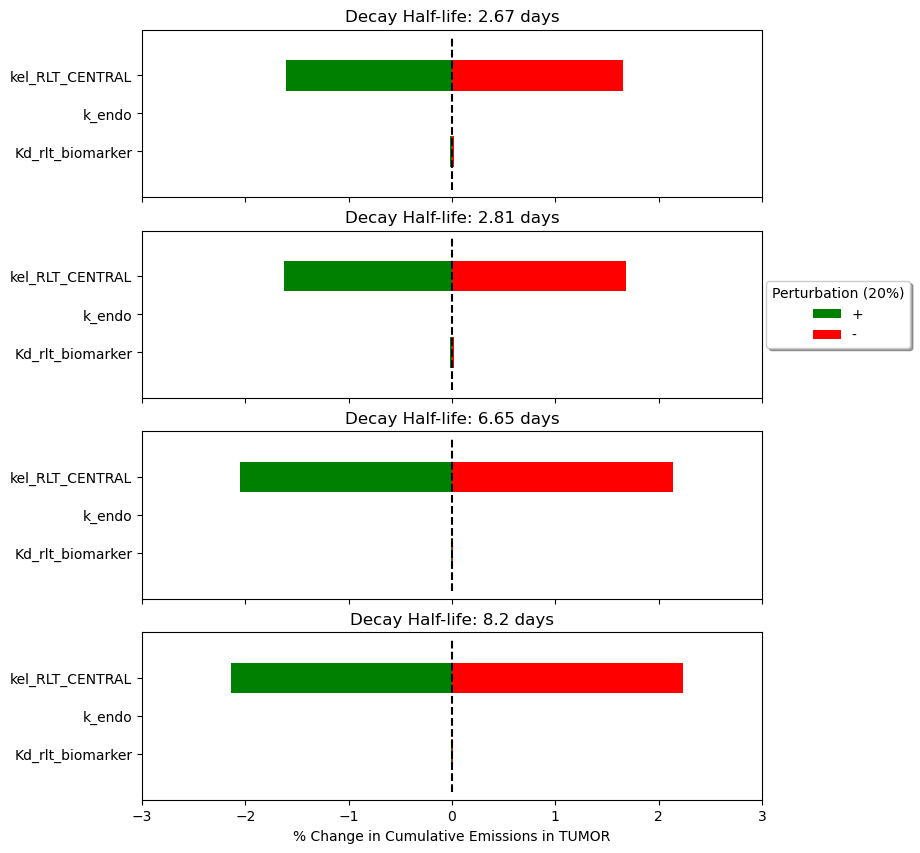

In [13]:
nplot = len(sim_outputs)
fig, axes = plt.subplots(nplot, sharex=True)
for i, halflife in enumerate(sim_outputs):
    sim_outs = sim_outputs[halflife]
    t_em_plus = []
    t_em_minus = []
    #print(halflife)
    for param in sim_outs:
        #print(param)
        em_base = sim_outs[param][0]["obs_Emission_TUMOR"][-1]
        em_plus = sim_outs[param][1]["obs_Emission_TUMOR"][-1]
        em_minus = sim_outs[param][2]["obs_Emission_TUMOR"][-1]
        #print(em_base, em_plus, em_minus)
        t_em_plus.append(100 * (em_plus - em_base) / em_base)
        t_em_minus.append(100 * (em_minus - em_base) / em_base)
    #print(test_parameters)
    #print(t_em_plus)
    axes[i].barh(test_parameters, t_em_plus, color='g', label='+')
    axes[i].barh(test_parameters, t_em_minus, color='r', label='-')
    axes[i].vlines(0, -1, 3, linestyle='--', color='k')
    axes[i].set_title("Decay Half-life: " + str(np.round(halflife/24, 2)) + " days")
    #break
axes[0].set_xlim((-3, 3))
axes[-1].set_xlabel("% Change in Cumulative Emissions in TUMOR")
fig.set_size_inches(8, 10)
axes[1].legend(loc='center right',
              title='Perturbation (20%)',
              bbox_to_anchor=(1.25, 0.5),
              fancybox=True, shadow=True)

From the changes in the emissions, we can see that the model with its nominal parameters is most sensitive locally to changes in the linear elimination rate. The longer the decay half-life, the more significant the effect. I suspect that the lack of sensitivity to the dissociation constant and endocytosis rate constant means that binding and uptake are sufficiently fast enough that the perturbations we tested had no effect. In the next couple of sections, we'll examine this a little more closely.

------

# 4. Further examining the role of endocytosis in facilitating targeted emissions

## 4-A. What if we turn off endocytosis?

In this section, we will perform an [in silico](https://en.wikipedia.org/wiki/In_silico) experiment in which we set the endocytosis rate constant to zero, turning off the cellular uptake of the RLT-Biomarker complex. 

![image](https://drive.google.com/thumbnail?id=1vqbRYRM3W_AEePtrVn0OcNPl5PXxJ991&sz=w400)

The RLT can still reversibly bind the Biomarker, approximating binding at the cell surface, but it won't be irreversibly internalized. We will simulate this case for each decay half-life and see how it affects the cumulative emissions in the `TUMOR` compartment. 

### Simulations

In [14]:
sim_outputs_2 = dict()
base_value = model.parameters['k_endo'].value
for rlt_halflife_hr in halflives_hr:
    # Set the RLT halflife:
    model.parameters['rlt_halflife'].value = rlt_halflife_hr
    # Simulate the model and collect the output.
    sim_out_base = pkpd.simulate(model, tspan_hr)
    # Set the value to zero
    model.parameters['k_endo'].value = 0.
    sim_out_off = pkpd.simulate(model, tspan_hr)
    # Simulate the model and collect the output.
    sim_outputs_2[rlt_halflife_hr] = (sim_out_base, sim_out_off)
    # Set the parameter back to its original value
    model.parameters['k_endo'].value = base_value

### Results

Now, let's plot the changes in the final cumulative targeted emissions from the TUMOR compartment:

(-60.0, 10.0)

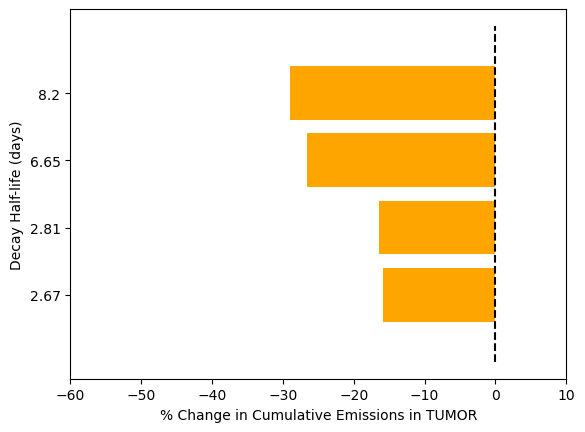

In [15]:
emissions = list()
for i, halflife in enumerate(sim_outputs_2):
    sim_outs = sim_outputs_2[halflife]
    em_base = sim_outs[0]["obs_Emission_TUMOR"][-1]
    em_zero = sim_outs[1]["obs_Emission_TUMOR"][-1]
    emissions.append(100 * (em_zero - em_base) / em_base)

plt.barh([str(np.round(hld, 2)) for hld in halflives_day], emissions, color='orange')
plt.vlines(0, -1, 4, linestyle='--', color='k')
plt.ylabel("Decay Half-life (days)")
plt.xlabel("% Change in Cumulative Emissions in TUMOR")
plt.xlim((-60, 10))

We can see that although the model was insensitive to perturbations in `k_endo` if we set it to zero, the targeted emissions were significantly reduced. The effect is most prominent, at nearly -30%, for the Iodine-131 half-life (8.2 days) and decreases with reductions in decay half-life down to around -15%. 

This computational experiment suggests that RLTs with longer decay half-lives depend more heavily on endocytosis to facilitate their `TUMOR` targeted emissions. Intuitively, this makes sense because the longer the decay half-life is, the more chance there is of the RLT being cleared before releasing its radioactive emissions when there is no endocytosis to trap it in the tumor cells.   

------

## 4-B. What if endocytosis is hindered?

A follow-up question to the results in the previous section is: What happens when endocytosis still happens but is hindered (i.e., slower)? In this section, we'll test some more significicant decreases in the endocytosis rate constant to get a better idea of when hindered endocytosis begins to degrade the tumor-targeted emissions. 

### Setup

We know from the local sensitivity analysis that changes of $\pm$20% to our endocytosis rate constant (0.1 s^-1) don't significantly change the targeted emissions. So, we'll examine more significant reductions from 10x to 10000x, covering a range of values for more progressively hindered uptake:

In [31]:
reduction_factors = [1, # reference value
           1/10, 1/100, 1/1000, 1/10000]

### Simulations

In [32]:
sim_outputs_2b = dict()
base_value = model.parameters['k_endo'].value
for rlt_halflife_hr in halflives_hr:
    sim_outputs_2b[rlt_halflife_hr] = dict()
    for factor in reduction_factors:
        # Set the RLT halflife:
        model.parameters['rlt_halflife'].value = rlt_halflife_hr
        # Adjust the parameter
        model.parameters['k_endo'].value = base_value * factor
        # Simulate the model and collect the output.
        sim_out = pkpd.simulate(model, tspan_hr)
        factor_key = str(np.round(factor, 4))
        #print(factor_key)
        sim_outputs_2b[rlt_halflife_hr][factor_key] = sim_out
        
# Set the parameter back to its original value
model.parameters['k_endo'].value = base_value

### Results

Let's examine how the final cumulative targeted emissions from the TUMOR compartment change:

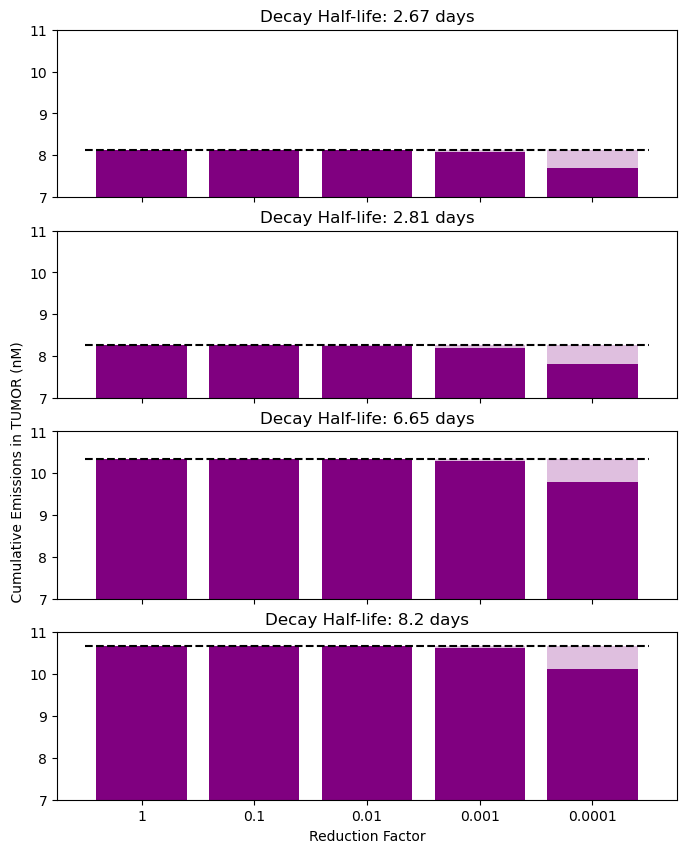

In [49]:
nplot = len(sim_outputs_2b)
fig, axes = plt.subplots(nplot, sharex=True)
for i, halflife in enumerate(sim_outputs_2b):
    sim_outs = sim_outputs_2b[halflife]
    emissions = list()
    for factor in sim_outs:
        #print(param)
        em = sim_outs[factor]["obs_Emission_TUMOR"][-1]
        emissions.append(em)
    #print(test_parameters)
    #print(t_em_plus)
    factors = list(sim_outs.keys())
    axes[i].bar(factors, [emissions[0]]*len(emissions), color='purple', alpha=0.25)
    axes[i].bar(factors, emissions, color='purple')
    axes[i].hlines(emissions[0], -0.5, 4.5, linestyle='--', color='k')
    axes[i].set_title("Decay Half-life: " + str(np.round(halflife/24, 2)) + " days")
    #break
    axes[i].set_ylim((7, 11))
axes[2].set_ylabel("                    Cumulative Emissions in TUMOR (nM)")
axes[-1].set_xlabel("Reduction Factor")
fig.set_size_inches(8, 10)

Interestingly, we can see that there is not a noticeable reduction in the tumor-targeted emissions until the endocytosis rate constant is reduced by a factor of 10,000 (0.0001 in the plot). This suggests that as long as the binding is moderately strong, endocytosis has to be severely hampered to have a pronounced effect on reducing targeted emissions. From the previous section, we know it's still an essential process for promoting tumor-targeted emissions, but the system is relatively insensitive to the actual rate of endocytosis. I suspect this may not be the case when the binding is weak, which we will test in the next section. 

------

## 4-C. What if endocytosis is hindered when biomarker binding is weak?

In this section, we'll re-test the decreases in the endocytosis rate constant for a case when the RLT-Biomarker binding is weak to see if the targeted emissions are more sensitive to reductions in endocytosis speed. In this case, we'll use a dissociation constant of 100 micromolar.  

### Simulations

In [54]:
sim_outputs_2c = dict()
base_value = model.parameters['k_endo'].value
base_value_kd = model.parameters['Kd_rlt_biomarker'].value
# Adjust the Kd for weaker binding
model.parameters['Kd_rlt_biomarker'].value = 100000. # nM = 100 uM
for rlt_halflife_hr in halflives_hr:
    sim_outputs_2c[rlt_halflife_hr] = dict()
    for factor in reduction_factors:
        # Set the RLT halflife:
        model.parameters['rlt_halflife'].value = rlt_halflife_hr
        # Adjust the parameter
        model.parameters['k_endo'].value = base_value * factor
        # Simulate the model and collect the output.
        sim_out = pkpd.simulate(model, tspan_hr)
        factor_key = str(np.round(factor, 4))
        #print(factor_key)
        sim_outputs_2c[rlt_halflife_hr][factor_key] = sim_out
        
# Set the parameter back to its original value
model.parameters['k_endo'].value = base_value
model.parameters['Kd_rlt_biomarker'].value = base_value_kd

### Results

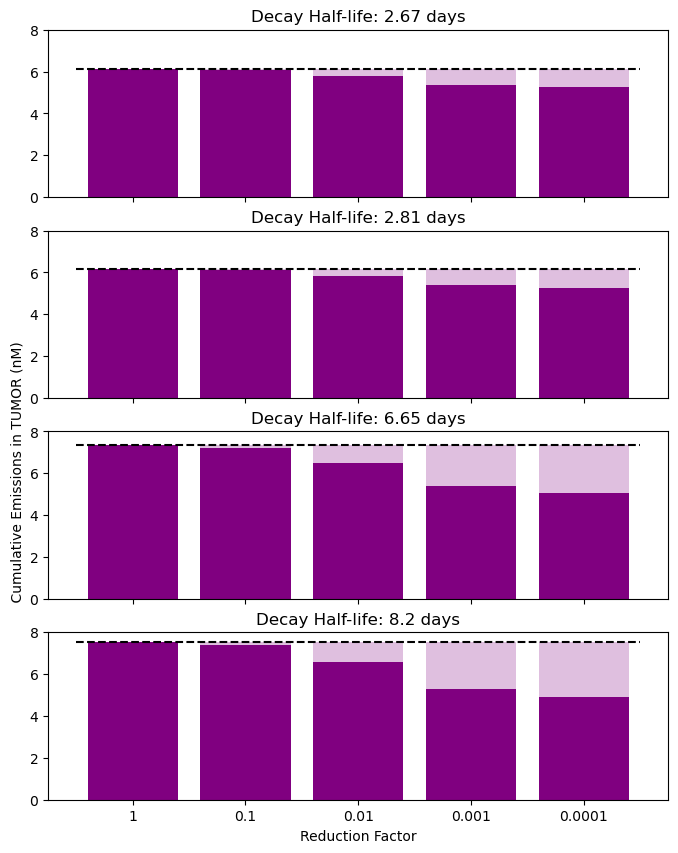

In [56]:
nplot = len(sim_outputs_2c)
fig, axes = plt.subplots(nplot, sharex=True)
for i, halflife in enumerate(sim_outputs_2c):
    sim_outs = sim_outputs_2c[halflife]
    emissions = list()
    for factor in sim_outs:
        #print(param)
        em = sim_outs[factor]["obs_Emission_TUMOR"][-1]
        emissions.append(em)
    #print(test_parameters)
    #print(t_em_plus)
    factors = list(sim_outs.keys())
    axes[i].bar(factors, [emissions[0]]*len(emissions), color='purple', alpha=0.25)
    axes[i].bar(factors, emissions, color='purple')
    axes[i].hlines(emissions[0], -0.5, 4.5, linestyle='--', color='k')
    axes[i].set_title("Decay Half-life: " + str(np.round(halflife/24, 2)) + " days")
    #break
    axes[i].set_ylim((0, 8))
axes[2].set_ylabel("                    Cumulative Emissions in TUMOR (nM)")
axes[-1].set_xlabel("Reduction Factor")
fig.set_size_inches(8, 10)

In this case, we can start to see a noticeable reduction in tumor-targeted emissions when the endocytosis rate constant is reduced by a factor of 100 (0.01 in the plot). The effect is more prominent when the half-life is longer, suggesting that those systems are more sensitive to reductions in the binding and uptake. Regardless, we can conclude that the endocytosis rate becomes much more critical when binding is weak in maintaining the targeted emissions. 

------

# 5. Further examining the role of Biomarker binding in facilitating targeted emissions

## 5-A. What if we turn off RLT-Biomarker binding?

In this section, we'll perform another [in silico](https://en.wikipedia.org/wiki/In_silico) experiment, but this time, we will set the RLT-Biomarker dissociation constant to infinity. Doing so with our model turns off the binding by making the forward binding rate constant $k_{on} = k_{off} / K_d = 0$ when $K_d \rightarrow \infty$; alternatively, we could also just set the biomarker initial concentration to zero for the same effect.  

![image](https://drive.google.com/thumbnail?id=1UC1H3MC3biMVbcxdealvTZdCaT_NgypB&sz=w400)

### Simulations

In [19]:
sim_outputs_3 = dict()
base_value = model.parameters['Kd_rlt_biomarker'].value
for rlt_halflife_hr in halflives_hr:
    # Set the RLT halflife:
    model.parameters['rlt_halflife'].value = rlt_halflife_hr
    # Simulate the model and collect the output.
    sim_out_base = pkpd.simulate(model, tspan_hr)
    # Set the value to zero
    model.parameters['Kd_rlt_biomarker'].value = np.inf
    sim_out_off = pkpd.simulate(model, tspan_hr)
    # Simulate the model and collect the output.
    sim_outputs_3[rlt_halflife_hr] = (sim_out_base, sim_out_off)
    # Set the parameter back to its original value
    model.parameters['Kd_rlt_biomarker'].value = base_value

### Results

Now, let's plot the changes in the final cumulative targeted emissions from the TUMOR compartment:

(-60.0, 10.0)

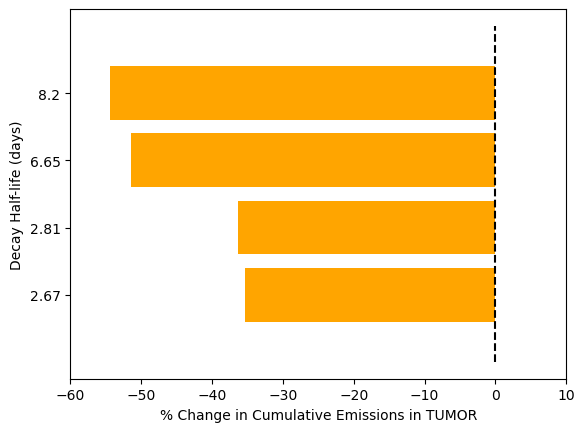

In [20]:
emissions = list()
for i, halflife in enumerate(sim_outputs_3):
    sim_outs = sim_outputs_3[halflife]
    em_base = sim_outs[0]["obs_Emission_TUMOR"][-1]
    em_zero = sim_outs[1]["obs_Emission_TUMOR"][-1]
    emissions.append(100 * (em_zero - em_base) / em_base)

plt.barh([str(np.round(hld, 2)) for hld in halflives_day], emissions, color='orange')
plt.vlines(0, -1, 4, linestyle='--', color='k')
plt.ylabel("Decay Half-life (days)")
plt.xlabel("% Change in Cumulative Emissions in TUMOR")
plt.xlim((-60, 10))

Similar to endocytosis, we can see that although the targeted emissions were insensitive to perturbations in `Kd_rlt_biomarker = 100 nM,` they are significantly reduced when the binding is eliminated. The effect is even more prominent than when endocytosis is turned off, leading to a 35-50% decrease. The overall trend for decay half-life is the same, though, with the longest decay half-life RLTs being the most affected.   

This in silico experiment reinforces the importance of the RLT's tumor-specific binding to the target biomarker in delivering radiation to tumors more effectively. Binding to the target biomarker is also the first step in cellular uptake, followed by endocytosis. So, eliminating RLT-biomarker binding ultimately hinders the selective retention of RLT in the tumor, which, as we saw from the results here, significantly reduces the amount of tumor-targeted emissions.   

-----

## 5-B. How strong does RLT-Biomarker binding need to be?

A follow-up question to the results in the previous section is: How strong does the binding need to be? In this section, we'll test a range of dissociation constants to see whether stronger binding can further enhance cellular uptake and whether weaker binding reduces the targeted emissions.  

### Setup

We know from the local sensitivity analysis that changes of $\pm$20% to our dissociation constant of 100 nM don't significantly change the targeted emissions. So, we'll examine the dissociation constant values over a more extensive range from 1 nM to 100 uM, covering from very strong binding to relatively weak binding:

In [34]:
# Values are in nM
kd_values = [1., 10.,
             100., # reference value
             1000., 10000., 100000.]

### Simulations

In [35]:
sim_outputs_3b = dict()
base_value = model.parameters['Kd_rlt_biomarker'].value
for rlt_halflife_hr in halflives_hr:
    sim_outputs_3b[rlt_halflife_hr] = dict()
    for kd_val in kd_values:
        # Set the RLT halflife:
        model.parameters['rlt_halflife'].value = rlt_halflife_hr
        # Adjust the parameter
        model.parameters['Kd_rlt_biomarker'].value = kd_val
        # Simulate the model and collect the output.
        sim_out = pkpd.simulate(model, tspan_hr)
        kd_key = str(int(kd_val))
        #print(factor_key)
        sim_outputs_3b[rlt_halflife_hr][kd_key] = sim_out
        
# Set the parameter back to its original value
model.parameters['Kd_rlt_biomarker'].value = base_value

### Results

Let's examine how the final cumulative targeted emissions from the TUMOR compartment change:

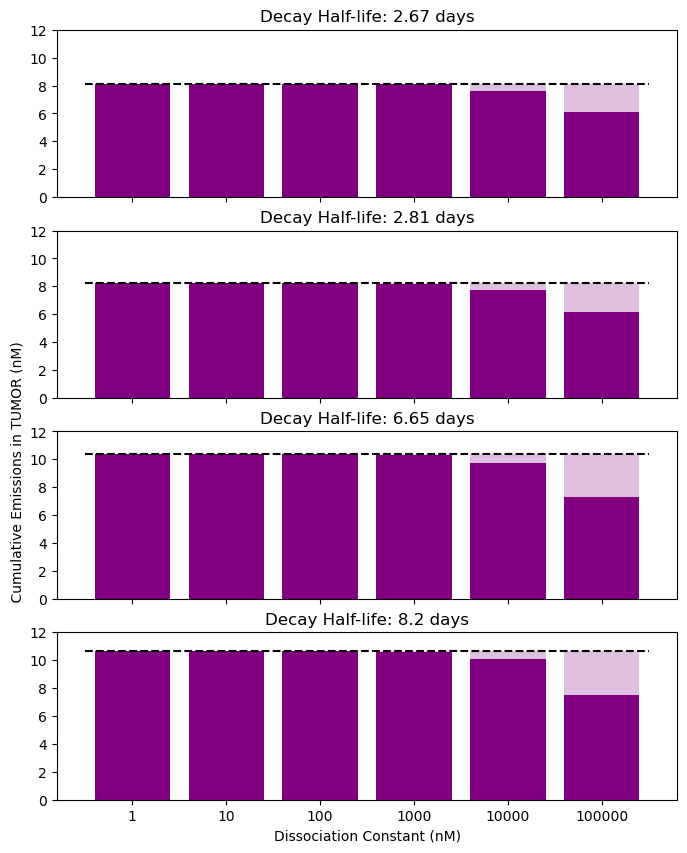

In [53]:
nplot = len(sim_outputs_3b)
fig, axes = plt.subplots(nplot, sharex=True)
for i, halflife in enumerate(sim_outputs_3b):
    sim_outs = sim_outputs_3b[halflife]
    emissions = list()
    for kd_val in sim_outs:
        #print(param)
        em = sim_outs[kd_val]["obs_Emission_TUMOR"][-1]
        emissions.append(em)
    #print(test_parameters)
    #print(t_em_plus)
    kd_vals = list(sim_outs.keys())
    axes[i].bar(kd_vals, [emissions[2]]*len(emissions), color='purple', alpha=0.25)
    axes[i].bar(kd_vals, emissions, color='purple')
    axes[i].hlines(emissions[2], -0.5, 5.5, linestyle='--', color='k')
    axes[i].set_title("Decay Half-life: " + str(np.round(halflife/24, 2)) + " days")
    #break
    axes[i].set_ylim((0, 12))
axes[2].set_ylabel("                    Cumulative Emissions in TUMOR (nM)")
axes[-1].set_xlabel("Dissociation Constant (nM)")
fig.set_size_inches(8, 10)

We can see from the above figure that as long as the binding is moderately strong (1 nM to 1 uM), there isn't a noticeable change in the targeted emissions. Only when the binding becomes weak ($\geq10$ uM) do we start seeing a reduction in the level of tumor-targeted emissions. It's interesting to note that increasing the binding strength by going from $K_d = 100$ nM to $K_d = 1$ nM doesn't result in a noticeable increase in targeted emissions, suggesting that there is a point at which the effect is saturated. It may be the case that other parameters like the endocytosis rate or biomarker concentration become the limiting factors.  

------

# Closing Thoughts

This post explored the importance of clearance, endocytosis, and biomarker binding in selectively delivering cytotoxic radioactive emissions to a tumor using a semi-mechanistic PK/PD model of a generic radioligand therapy (RLT). We also further explored the roles of endocytosis and biomarker binding in facilitating tumor-targeted radioactive emissions. 

Our results suggest that clearance can significantly affect the tumor-targeted emissions, particularly for longer half-life radioisotopes. Although the targeted emission levels were not sensitive to perturbations to the endocytosis rate or RLT-Biomarker dissociation constant around their nominal values, we found that they are indeed critical factors that facilitate selective retention of the RLT in the tumor cells and promote targeted emissions. When binding is moderately strong, the targeted emissions are not very sensitive to the endocytosis rate. However, when binding is weak, the rate of endocytosis becomes more critical, and hindering it can lead to noticeable reductions in targeted emissions. As the first step in cellular uptake, biomarker binding is essential in this process, and our results suggest the targeted emissions are optimized when binding is moderately strong (dissociation constants $\leq1$ uM).   

As in [RLT Part 2](https://blakeaw.github.io/2024-10-17-radiligand-therapy-2/), this analysis is limited by the fact that we didn't factor in the type of radiation or its emission energy generated by different radionuclides, which is another vital element in the overall cytotoxicity of an RLT.  

If you're interested, I'd encourage you to take the RLT model here, adapt it as needed, and perform your own analyses! If you do, be sure to let me know what you find.   

Thanks for reading, and have a nice day! Do you feel like these results make sense? Feel free to message me and let me know what you think or if you have any questions or want to discuss. I'm also open to feedback and suggestions for future posts, so if there is something you think I should cover, let me know! This is my last post on RLT before moving on to the subsequent precision cancer therapy. However, you can still drop me a line if you want to explore RLT further; I'm happy to help you adapt the model and get it running or explore other aspects of interest. You can contact me on [LinkedIn](https://www.linkedin.com/in/blakewilson3/).

Lastly, please share this post with anyone else who might be interested. It is a massive help to me, as it increases the blog's visibility and can help more people discover my work. Also, keep an eye out for future posts.

Until next time -- Blake

## Acknowledgements/Disclosures

[Grammarly](https://app.grammarly.com/) was used for proofreading and editing. 

Schematics were created using [Inkscape](https://inkscape.org/) and [GIMP](https://www.gimp.org/).

------
------

Like this content? You can follow this blog and get updated about new posts via my blog's RSS/Atom Feed.

------
------

If you are so inclined, you can also be a financial supporter of my open-source work and content through Ko-fi:

[![ko-fi](https://ko-fi.com/img/githubbutton_sm.svg)](https://ko-fi.com/J3J4ZUCVU)

------
------

**Other related posts you might like:**

[Radioligand Therapy (RLT) Part 1 - An Overview](https://blakeaw.github.io/2024-09-22-radioligand-therapy-1/)

[Radioligand Therapy (RLT) Part 2 - Modeling how radionuclide half-life affects tumor targeting and off-target emissions using a semi-mechanistic PK/PD approach](https://blakeaw.github.io/2024-10-17-radiligand-therapy-2/)

[Modeling Drug Dynamics using Programmatic PK/PD Models in Python](https://blakeaw.github.io/2023-10-23-pysb-pkpd/)

------